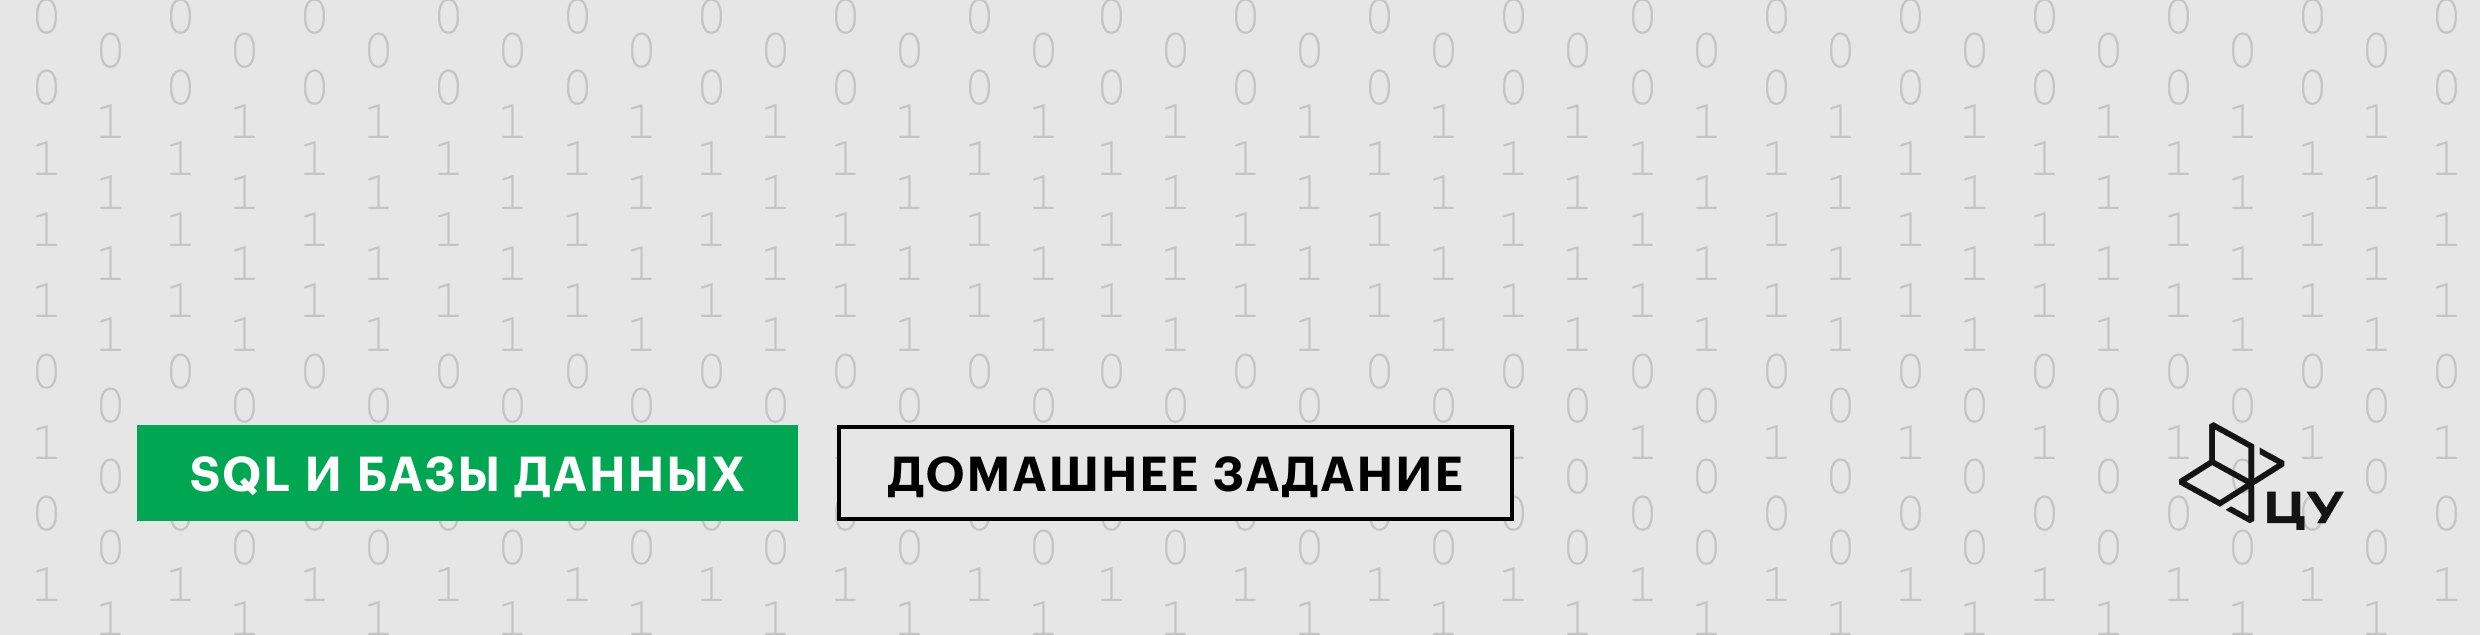

# Домашнее задание по теме Разработка запросов к одной таблице

Мы подготовили для тебя задачи, которые помогут закрепить пройденный материал.

В задании нужно написать запросы SQL к базе данных, которая используется в курсе. Описание таблиц и схему БД можно посмотреть тут:

https://centraluniversity.yonote.ru/share/0188ee4d-d0bb-4654-9d49-87dab28e9550/doc/tablicy-ispolzuemye-v-kurse-sql-i-bazy-dannyh-kXDYWB70FN


Подготовленное решение (данный файл) нужно сдать на проверку.


In [ ]:
import os,requests,time;url = "http://sql-exercise.sql-exercise-prod.svc.cluster.local/"
if os.path.exists("py_workshop.py"):
    os.remove("py_workshop.py")
if not os.path.exists("py_workshop.py"):
    response = requests.get(f"{url}get_py_workshop")
    if response.status_code == 200: 
        with open("py_workshop.py", "wb") as f: f.write(response.content);time.sleep(1)
# Проверь, что config.yaml (надо заполнить по инструкции) и py_workshop.py (скачается автоматически) находятся в папке с этим ноутбуком
from py_workshop import *;runner.set_url(url);runner.logon();schema_name = runner.user_schema

runner.course = 'sql'
runner.material( 'sqldb_an26_single_table_hw', course_launch='dbsql_an_onl_26_fall')

# Часть 1. Введение в SQL и базы данных

### Задача 1. Таблицы pizza и pizza_order с ключами (баллы: 0.5)
Все задания курса можно полностью выполнить в Jupyter Notebook. При желании можно использовать клиентское программное обеспечение, например DBeaver.

В этом задании ты создашь таблицы `pizza` и `pizza_order` в своей схеме PostgreSQL. В заготовке уже настроены первичные ключи и внешний ключ из `pizza_order.pizza_id` в `pizza.pizza_id`.

Скопируй SQL-код из описания в ячейку **DDL и DML код**. Замени каждую заглушку вместе с квадратными скобками на подходящий SQL-код или значение.

```sql
DROP TABLE IF EXISTS {schema_name}.pizza_order;
DROP TABLE IF EXISTS {schema_name}.pizza;

CREATE TABLE {schema_name}.pizza (
    pizza_id INTEGER PRIMARY KEY,
    pizza_name TEXT NOT NULL,
    price NUMERIC(10, 2) NOT NULL
);

CREATE TABLE {schema_name}.pizza_order (
    order_id INTEGER PRIMARY KEY,
    pizza_id INTEGER NOT NULL REFERENCES {schema_name}.pizza(pizza_id),
    order_time TIMESTAMP WITH TIME ZONE NOT NULL,
    [ОПРЕДЕЛЕНИЕ СТОЛБЦА quantity ЦЕЛОЧИСЛЕННОГО ТИПА]
);

INSERT INTO {schema_name}.pizza (pizza_id, pizza_name, price)
VALUES
    (1, 'Margherita', 500.50),
    (2, 'Pepperoni', 650.00),
    (3, 'Hawaiian', 700.75),
    (4, 'Four Cheese', 750.00),
    (5, 'Meat Feast', 850.00),
    (6, '[НАЗВАНИЕ ШЕСТОЙ ПИЦЦЫ]', [ЦЕНА ШЕСТОЙ ПИЦЦЫ]);

INSERT INTO {schema_name}.pizza_order (order_id, pizza_id, order_time, quantity)
VALUES
    (1, 1, TIMESTAMP WITH TIME ZONE '2026-08-01 12:00:00+03', [КОЛИЧЕСТВО В ПЕРВОМ ЗАКАЗЕ]),
    (2, 2, TIMESTAMP WITH TIME ZONE '2026-08-01 12:30:00+03', [КОЛИЧЕСТВО ВО ВТОРОМ ЗАКАЗЕ]),
    (3, [СУЩЕСТВУЮЩИЙ pizza_id], TIMESTAMP WITH TIME ZONE '[ДАТА И ВРЕМЯ ТРЕТЬЕГО ЗАКАЗА С ЧАСОВЫМ ПОЯСОМ]', [КОЛИЧЕСТВО В ТРЕТЬЕМ ЗАКАЗЕ]);
```

**Что нужно сделать?**

1. В DDL таблицы `pizza_order` замени заглушку определением столбца `quantity` целочисленного типа.
2. В DML таблицы `pizza` задай название и цену шестой пиццы.
3. В DML таблицы `pizza_order` укажи количество для двух готовых заказов.
4. Заполни заглушки третьего заказа: выбери существующий `pizza_id`, дату и время с часовым поясом и количество.

После выполнения задания в таблице `pizza` должно быть не менее шести строк, а в `pizza_order` — не менее трёх строк.



In [ ]:
%%exec_sql cell_1_1
-- DDL и DML код. Указывай правильную схему. Соединение postgres 

DROP TABLE IF EXISTS {schema_name}.pizza_order;
DROP TABLE IF EXISTS {schema_name}.pizza;

CREATE TABLE {schema_name}.pizza (
    pizza_id INTEGER PRIMARY KEY,
    pizza_name TEXT NOT NULL,
    price NUMERIC(10, 2) NOT NULL
);

CREATE TABLE {schema_name}.pizza_order (
    order_id INTEGER PRIMARY KEY,
    pizza_id INTEGER NOT NULL REFERENCES {schema_name}.pizza(pizza_id),
    order_time TIMESTAMP WITH TIME ZONE NOT NULL,
    [ОПРЕДЕЛЕНИЕ СТОЛБЦА quantity ЦЕЛОЧИСЛЕННОГО ТИПА]
);

INSERT INTO {schema_name}.pizza (pizza_id, pizza_name, price)
VALUES
    (1, 'Margherita', 500.50),
    (2, 'Pepperoni', 650.00),
    (3, 'Hawaiian', 700.75),
    (4, 'Four Cheese', 750.00),
    (5, 'Meat Feast', 850.00),
    (6, '[НАЗВАНИЕ ШЕСТОЙ ПИЦЦЫ]', [ЦЕНА ШЕСТОЙ ПИЦЦЫ]);

INSERT INTO {schema_name}.pizza_order (order_id, pizza_id, order_time, quantity)
VALUES
    (1, 1, TIMESTAMP WITH TIME ZONE '2026-08-01 12:00:00+03', [КОЛИЧЕСТВО В ПЕРВОМ ЗАКАЗЕ]),
    (2, 2, TIMESTAMP WITH TIME ZONE '2026-08-01 12:30:00+03', [КОЛИЧЕСТВО ВО ВТОРОМ ЗАКАЗЕ]),
    (3, [СУЩЕСТВУЮЩИЙ pizza_id], TIMESTAMP WITH TIME ZONE '[ДАТА И ВРЕМЯ ТРЕТЬЕГО ЗАКАЗА С ЧАСОВЫМ ПОЯСОМ]', [КОЛИЧЕСТВО В ТРЕТЬЕМ ЗАКАЗЕ]);


In [ ]:
%%sql_query cell_1_2
-- Задача 1. Ячейка 2. Запросы SQL Select. Соединение postgres 



In [ ]:
%%sql_db_check_submit cell_1_3
--Проверка БД для задачи 1. Проверка содержимого БД
--Запусти ячейку для проверки


# Часть 2. Разработка запросов к одной таблице

### Задача 2. Выборка строк из таблицы клиентов (баллы: 0.5)
Выведи 10 строк из таблицы shop_customers. Нужно вывести все столбцы в том порядке, в котором они идут в таблице.

Используй таблицы:
- shop_customers.



In [ ]:
%%sql_query cell_2_1
-- Задача 2. Ячейка 1. Напиши SQL-запрос. Соединение postgres 



In [ ]:
%%sql_query_submit cell_2_2
--Проверка запроса для задачи 2. Отправь SQL-запрос на проверку


### Задача 3. Уникальные статусы заказов (баллы: 0.5)
Выведи все уникальные статусы заказов из таблицы shop_orders. Отсортируй значения по возрастанию.

Результат должен содержать столбцы:
- **unique_order_status** — статус заказа.

Используй таблицы:
- shop_orders.



In [ ]:
%%sql_query cell_3_1
-- Задача 3. Ячейка 1. Напиши SQL-запрос. Соединение postgres 



In [ ]:
%%sql_query_submit cell_3_2
--Проверка запроса для задачи 3. Отправь SQL-запрос на проверку


### Задача 4. Дата первого заказа (баллы: 0.5)
В таблице shop_orders нужно найти дату создания первого заказа.

Результат должен содержать столбцы:
- **order_date** — дата первого заказа.

Используй таблицы:
- shop_orders.



In [ ]:
%%sql_query cell_4_1
-- Задача 4. Ячейка 1. Напиши SQL-запрос. Соединение postgres 



In [ ]:
%%sql_query_submit cell_4_2
--Проверка запроса для задачи 4. Отправь SQL-запрос на проверку


### Задача 5. Дата последнего заказа (баллы: 1)
В таблице shop_orders нужно найти дату создания последнего заказа.

Результат должен содержать столбцы:
- **order_date** — дата заказа.

Используй таблицы:
- shop_orders.



In [ ]:
%%sql_query cell_5_1
-- Задача 5. Ячейка 1. Напиши SQL-запрос. Соединение postgres 



In [ ]:
%%sql_query_submit cell_5_2
--Проверка запроса для задачи 5. Отправь SQL-запрос на проверку


### Задача 6. Топ-5 самых дорогих заказов (баллы: 1)
Из таблицы shop_orders выведи пять самых дорогих заказов.

Результат должен содержать столбцы:
- **order_id** — идентификатор заказа;
- **order_date** — дата заказа;
- **total_amount** — сумма заказа.

Используй таблицы:
- shop_orders.



In [ ]:
%%sql_query cell_6_1
-- Задача 6. Ячейка 1. Напиши SQL-запрос. Соединение postgres 



In [ ]:
%%sql_query_submit cell_6_2
--Проверка запроса для задачи 6. Отправь SQL-запрос на проверку


### Задача 7. Поиск клиентов с Gmail (баллы: 1)
Из таблицы shop_customers найди 10 клиентов, адрес электронной почты которых находится на домене gmail.com.

Результат должен содержать столбцы:
- **customer_id** — идентификатор клиента;
- **email** — адрес электронной почты клиента;
- **created_at** — дата и время создания записи.

Используй таблицы:
- shop_customers.



In [ ]:
%%sql_query cell_7_1
-- Задача 7. Ячейка 1. Напиши SQL-запрос. Соединение postgres 



In [ ]:
%%sql_query_submit cell_7_2
--Проверка запроса для задачи 7. Отправь SQL-запрос на проверку


### Задача 8. Дорогие и дешёвые товары (баллы: 1)
Из таблицы shop_products выведи информацию о дорогих и дешёвых товарах нашего магазина.
Дешёвыми считай товары стоимостью менее 10 000, а дорогими — товары стоимостью более 300 000.

Результат должен содержать столбцы:
- **product_id** — идентификатор товара;
- **price** — стоимость товара;
- **name** — название товара.

Используй таблицы:
- shop_products.



In [ ]:
%%sql_query cell_8_1
-- Задача 8. Ячейка 1. Напиши SQL-запрос. Соединение postgres 



In [ ]:
%%sql_query_submit cell_8_2
--Проверка запроса для задачи 8. Отправь SQL-запрос на проверку


### Задача 9. Товары за декабрь 2022 (баллы: 1)
Из таблицы shop_products выведи товары, относящиеся к категории с идентификатором 1 и созданные в декабре 2022 года.

Результат должен содержать столбцы:
- **product_id** — идентификатор товара;
- **price** — стоимость товара;
- **name** — название товара;
- **created_at** — дата и время создания товара.

Используй таблицы:
- shop_products.



In [ ]:
%%sql_query cell_9_1
-- Задача 9. Ячейка 1. Напиши SQL-запрос. Соединение postgres 



In [ ]:
%%sql_query_submit cell_9_2
--Проверка запроса для задачи 9. Отправь SQL-запрос на проверку


### Задача 10. Полное имя клиента одной строкой (баллы: 1)
Из таблицы shop_customers выведи информацию о клиентах.

Результат должен содержать столбцы:
- **customer_id** — идентификатор клиента;
- **first_name** — имя клиента;
- **last_name** — фамилия клиента;
- **full_name** — имя и фамилия клиента, разделённые пробелом.

Используй таблицы:
- shop_customers.



In [ ]:
%%sql_query cell_10_1
-- Задача 10. Ячейка 1. Напиши SQL-запрос. Соединение postgres 



In [ ]:
%%sql_query_submit cell_10_2
--Проверка запроса для задачи 10. Отправь SQL-запрос на проверку


### Задача 11. Заказы с долгой доставкой (баллы: 1)
Из таблицы shop_orders выведи завершённые заказы (order_status = 'Completed'), созданные 10 июля 2024 года и доставленные более чем за пять дней.

Результат должен содержать столбцы:
- **order_id** — идентификатор заказа;
- **customer_id** — идентификатор клиента;
- **order_date** — дата заказа;
- **delivery_date** — дата доставки.

Используй таблицы:
- shop_orders.



In [ ]:
%%sql_query cell_11_1
-- Задача 11. Ячейка 1. Напиши SQL-запрос. Соединение postgres 



In [ ]:
%%sql_query_submit cell_11_2
--Проверка запроса для задачи 11. Отправь SQL-запрос на проверку


### Задача 12. Заказы за сентябрь 2024 (баллы: 1)
Из таблицы shop_orders выведи заказы, доставленные в сентябре 2024 года, сумма которых превышает 500 000.

Результат должен содержать столбцы:
- **order_id** — идентификатор заказа;
- **customer_id** — идентификатор клиента;
- **delivery_date** — дата доставки;
- **total_amount** — сумма заказа.

Используй таблицы:
- shop_orders.



In [ ]:
%%sql_query cell_12_1
-- Задача 12. Ячейка 1. Напиши SQL-запрос. Соединение postgres 



In [ ]:
%%sql_query_submit cell_12_2
--Проверка запроса для задачи 12. Отправь SQL-запрос на проверку
